In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#initializing dataframe "Housing.csv"
df = pd.read_csv("Housing.csv")

In [ ]:
df.shape # checking the shape of the dataframe

(545, 13)

In [ ]:
df.info() # information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe() # detailed description of the dataframe

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isna().sum() # checking the number of na values

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### Baseline Model: Numeric-Only Features

In [ ]:
# Baseline: using only originally-numeric columns, per assignment instructions
numeric_cols = df.select_dtypes(include=np.number).columns.drop('price')

X_baseline = df[numeric_cols]
y_baseline = df['price']

from sklearn.model_selection import train_test_split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.3, random_state=42)

lr_baseline = LinearRegression()
lr_baseline.fit(X_train_b, y_train_b)
y_pred_b = lr_baseline.predict(X_test_b)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared
r2 = r2_score(y_test_b, y_pred_b)
print(f"R2 Score: {r2:.4f}")

# Calculate Mean Squared Error
mse = mean_squared_error(y_test_b, y_pred_b)
print(f"Mean Squared Error: {mse:.2f}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test_b, y_pred_b)
print(f"Mean Absolute Error: {mae:.2f}")

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

# Display prediction results (first 5 predictions vs actual)
predictions_df = pd.DataFrame({'Actual': y_test_b, 'Predicted': y_pred_b})
print("\nFirst 5 Prediction Results:")
display(predictions_df.head())

R2 Score: 0.5253
Mean Squared Error: 2044165115591.79
Mean Absolute Error: 1065137.83
Root Mean Squared Error: 1429743.02

First 5 Prediction Results:


,Actual,Predicted
316,4060000,6.298756e+06
77,6650000,6.412300e+06
360,3710000,3.301998e+06
90,6440000,4.251721e+06
493,2800000,3.436733e+06


### Exploratory Data Analysis (EDA)

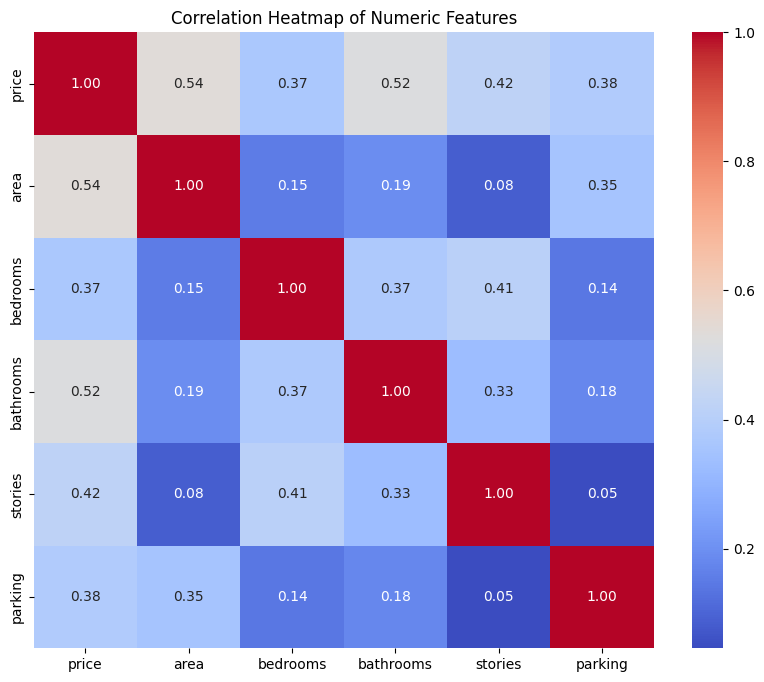

In [ ]:
# Correlation Heatmap of Numeric Columns
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

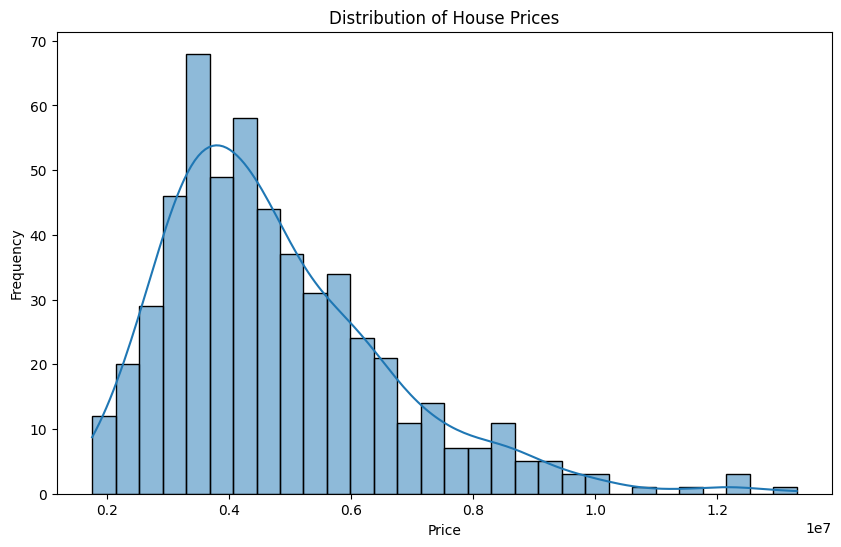

In [ ]:
# Distribution of Price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

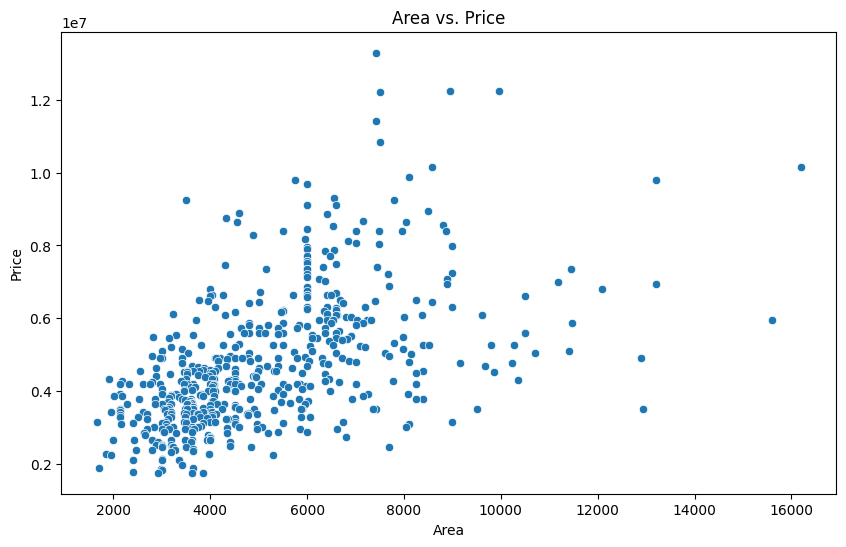

In [ ]:
# Area vs. Price Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
plt.title('Area vs. Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

### Data Preprocessing: Handling Categorical Variables

In [ ]:
# Encoding Binary Categorical Variables
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Mapping 'yes' to 1 and 'no' to 0
def map_binary(x):
    return x.map({'yes': 1, 'no': 0})

df[binary_cols] = df[binary_cols].apply(map_binary)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [ ]:
# One-Hot Encoding Multi-Category Variables
# One-hot encode 'furnishingstatus'
furnishing_status_dummies = pd.get_dummies(df['furnishingstatus'], prefix='furnishing', drop_first=True)

# Concatenate the new dummy variables to the original dataframe
df = pd.concat([df, furnishing_status_dummies], axis=1)

# Drop the original 'furnishingstatus' column
df.drop('furnishingstatus', axis=1, inplace=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_semi-furnished,furnishing_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [ ]:
# Data Preprocessing: Feature Scaling
from sklearn.preprocessing import MinMaxScaler

# List of variables to scale (all numerical columns except 'price' and dummy variables)
# Note: 'area', 'bedrooms', 'bathrooms', 'stories', 'parking' are the original numerical features.
# The dummy variables 'furnishing_semi-furnished', 'furnishing_unfurnished' are already 0/1 and do not need scaling in this context.

vars_to_scale = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaler to the selected columns
df[vars_to_scale] = scaler.fit_transform(df[vars_to_scale])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_semi-furnished,furnishing_unfurnished
0,13300000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,False,False
1,12250000,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,False,False
2,12250000,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,True,False
3,12215000,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,False,False
4,11410000,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,False,False


### Model Building: Splitting Data into Training and Testing Sets

In [ ]:
# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (381, 13)
X_test shape: (164, 13)
y_train shape: (381,)
y_test shape: (164,)


### Model Building: Training the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lr = LinearRegression()

# Train the model using the training data
lr.fit(X_train, y_train)

LinearRegression()

#### Making Predictions

In [ ]:
# Make predictions on the test set
y_pred = lr.predict(X_test)

#### Evaluating Model Performance

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

# Display prediction results (first 5 predictions vs actual)
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nFirst 5 Prediction Results:")
display(predictions_df.head())

# Display model coefficients
coefficients = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
display(coefficients)

R2 Score: 0.6463
Mean Squared Error: 1523019469501.29
Mean Absolute Error: 920392.94
Root Mean Squared Error: 1234106.75

First 5 Prediction Results:


,Actual,Predicted
316,4060000,5.372313e+06
77,6650000,7.069241e+06
360,3710000,3.099291e+06
90,6440000,4.526447e+06
493,2800000,3.281574e+06



Model Coefficients:


,Coefficient
area,3.685330e+06
bedrooms,4.044657e+05
bathrooms,3.344254e+06
stories,1.251803e+06
mainroad,4.080737e+05
guestroom,2.757105e+05
basement,4.826035e+05
hotwaterheating,6.163754e+05
airconditioning,6.858393e+05
parking,9.093337e+05


#### Visualizing Predictions vs. Actuals

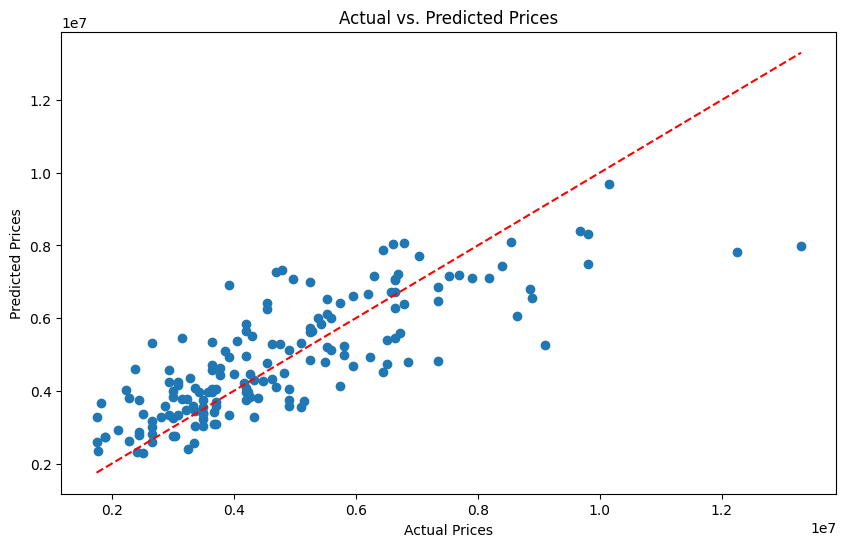

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.show()

### Summary: Baseline vs. Extended Model

| Metric | Baseline (Numeric-Only) | Extended (With Encoded Categoricals) |
|---|---|---|
| R² Score | 0.5253 | 0.6463 |
| MAE | 1,065,137.83 | 920,392.94 |
| MSE | 2,044,165,115,591.79 | 1,523,019,469,501.29 |
| RMSE | 1,429,743.02 | 1,234,106.75 |

The assignment instructions specify using the remaining numeric columns as features. As a baseline, this was done first using only `area`, `bedrooms`, `bathrooms`, `stories`, and `parking`, achieving an R² of 0.53.

To improve on this, the categorical columns were encoded (binary yes/no mapping for `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, and one-hot encoding for `furnishingstatus`) and included as additional features. This extended model improved R² to 0.65 and reduced error across all three metrics, suggesting that features like air conditioning and preferred area meaningfully affect house price beyond what the purely numeric columns capture.